In [1]:
import os
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mllabs 
mllabs.__version__

2026-05-31 13:12:16.286102: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 13:12:16.619120: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 13:12:18.027185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

'0.8.0'

In [2]:
data_path = Path('data')

if not os.path.exists(data_path):
    os.mkdir(data_path)
    !kaggle competitions download -c playground-series-s6e5
    !unzip playground-series-s6e5.zip -d data
    !rm playground-series-s6e5.zip
    !kaggle datasets download aadigupta1601/f1-strategy-dataset-pit-stop-prediction
    !unzip f1-strategy-dataset-pit-stop-prediction.zip -d data
    !rm f1-strategy-dataset-pit-stop-prediction.zip

In [3]:
!ls -l data

total 88764
-rw-r--r-- 1 sun9sun9 sun9sun9 13166466 Apr  8 18:59 f1_strategy_dataset_v4.csv
-rw-r--r-- 1 sun9sun9 sun9sun9  1693499 Apr 23 17:51 sample_submission.csv
-rw-r--r-- 1 sun9sun9 sun9sun9 22312035 Apr 23 17:51 test.csv
-rw-r--r-- 1 sun9sun9 sun9sun9 53714242 Apr 23 17:51 train.csv


In [4]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

In [7]:
ploader = PolarsLoader(predefined_types={'id': pl.Int64, 'PitNextLap': pl.Float32})
ploader.fit([data_path / 'train.csv', data_path / 'test.csv', data_path / 'f1_strategy_dataset_v4.csv'])
df_type = ploader.df_type_
df_type

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8
feature,,,,,,,,,,
Compound,NaN,NaN,0.0,728676.0,5.333333,String,False,False,False,False
Cumulative_Degradation,-274.564000,2412.431,0.0,728676.0,103836.666667,Float64,True,True,True,False
Driver,NaN,NaN,0.0,728676.0,573.000000,String,False,False,False,False
LapNumber,1.000000,78.000,0.0,728676.0,77.666667,Int64,True,True,True,True
LapTime (s),67.012000,2526.253,0.0,728676.0,36261.333333,Float64,True,True,True,False
LapTime_Delta,-2403.895000,2433.472,0.0,728676.0,51348.000000,Float64,True,True,True,False
Normalized_TyreLife,0.012821,1.000,0.0,101371.0,1602.000000,Float64,True,True,True,True
PitNextLap,0.000000,1.000,0.0,540511.0,2.000000,Int64,True,True,True,True
PitStop,0.000000,1.000,0.0,728676.0,2.000000,Int64,True,True,True,True


In [8]:
pconv = PandasConverter(index_col= 'id')
expr_dict = {
    'Position_Change': pl.col('Position_Change').cast(pl.Int8),
}
expr_proc = ExprProcessor(expr_dict)

In [9]:
df_train = pconv.fit_transform(
    expr_proc.fit_transform(ploader.transform([data_path / 'train.csv']))
)
df_train.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.490997,-7.564000,21.018999,0.714286,5,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095001,-32.617001,-223.207001,0.346154,-3,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945000,-7.540000,-100.528999,0.819444,3,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361000,-7.324000,-7.324000,0.076923,0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.877998,8.965000,-14.139000,0.361111,3,0.0


In [10]:
loader = make_pipeline(ploader, expr_proc, pconv)
df_test = loader.transform([data_path / 'test.csv'])
df_org = loader.transform([data_path / 'f1_strategy_dataset_v4.csv']).pipe(
    lambda x: x.set_index(pd.Index(x.index + 1, name = 'id'))
)

In [11]:
df_train.shape, df_org.shape, df_test.shape

((439140, 15), (101371, 16), (188165, 14))

In [12]:
set(df_org.columns) -  set(df_train.columns), set(df_train.columns) - set(df_test.columns)

({'Normalized_TyreLife'}, {'PitNextLap'})

In [13]:
y = 'PitNextLap'

In [14]:
df_type.query('n_unique < 20 or dtype == "String"')

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8
feature,,,,,,,,,,
Compound,NaN,NaN,0.0,728676.0,5.333333,String,False,False,False,False
Driver,NaN,NaN,0.0,728676.0,573.000000,String,False,False,False,False
PitNextLap,0.0,1.0,0.0,540511.0,2.000000,Int64,True,True,True,True
PitStop,0.0,1.0,0.0,728676.0,2.000000,Int64,True,True,True,True
Race,NaN,NaN,0.0,728676.0,26.666667,String,False,False,False,False
Stint,1.0,8.0,0.0,728676.0,8.000000,Int64,True,True,True,True
Year,2022.0,2025.0,0.0,728676.0,4.000000,Int64,True,True,True,False


In [15]:
df_train['PitNextLap'] = df_train['PitNextLap'].astype('int8')
df_org['PitNextLap'] = df_org['PitNextLap'].astype('int8')

In [16]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   Driver                  439140 non-null  category
 1   Compound                439140 non-null  category
 2   Race                    439140 non-null  category
 3   Year                    439140 non-null  int16   
 4   PitStop                 439140 non-null  int8    
 5   LapNumber               439140 non-null  int8    
 6   Stint                   439140 non-null  int8    
 7   TyreLife                439140 non-null  float32 
 8   Position                439140 non-null  int8    
 9   LapTime (s)             439140 non-null  float32 
 10  LapTime_Delta           439140 non-null  float32 
 11  Cumulative_Degradation  439140 non-null  float32 
 12  RaceProgress            439140 non-null  float32 
 13  Position_Change         439140 non-null  int8    
 14  PitNextLap     

In [17]:
X_bin = ['PitStop']
X_nom = ['Driver', 'Compound', 'Race']
X_int = ['Year', 'LapNumber', 'Stint', 'Position', 'Position_Change']
X_cont = ['TyreLife', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress']

In [18]:
pd.concat([
    df_train[X_nom].apply(set).rename('train'),
    df_test[X_nom].apply(set).rename('test')
], axis=1).apply(
    lambda x: x['test'] - x['train'], axis=1
)

Driver      {}
Compound    {}
Race        {}
dtype: object

In [19]:
pd.concat([
    df_train[X_nom].apply(set).rename('train'),
    df_org[X_nom].apply(set).rename('org')
], axis=1).apply(
    lambda x: x['org'] - x['train'], axis=1
)

Driver                                               {}
Compound                                         {None}
Race        {Pre-Season Track Session, Pre-Season Test}
dtype: object

In [20]:
pd.concat([
    df_train[X_int].apply(set).rename('train'),
    df_test[X_int].apply(set).rename('test')
], axis=1).apply(
    lambda x: x['test'] - x['train'], axis=1
)

Year               {}
LapNumber          {}
Stint              {}
Position           {}
Position_Change    {}
dtype: object

In [21]:
pd.concat([
    df_train[X_cont].apply(set).rename('train'),
    df_test[X_cont].apply(set).rename('test')
], axis=1).apply(
    lambda x: x['test'] - x['train'], axis=1
).pipe(
    lambda x: pd.concat([x, x.apply(len).rename('cnt')], axis=1)
)

,0,cnt
TyreLife,{},0
LapTime (s),"{78.25800323486328, 78.16600036621094, 78.4160...",2842
LapTime_Delta,"{0.8870000243186951, 1.1649999618530273, 2.167...",4575
Cumulative_Degradation,"{0.10599999874830246, 1.0709999799728394, 2.03...",11673
RaceProgress,"{0.027571428567171097, 0.7301587462425232, 0.0...",102


In [22]:
df_train['TyreLife'].unique()

array([39. ,  7. , 22. ,  2. ,  6. , 26. , 16. ,  9. ,  4. , 10. , 12. ,
        1. ,  5. , 18. ,  8. , 17. , 19. , 14. , 15. , 27. , 13. , 24. ,
       37. , 21. , 32. , 20. , 23. , 11. , 25. , 29. , 38. ,  3. , 45. ,
       30. , 34. , 40. , 28. , 36. , 31. , 49. , 41. , 35. , 44. , 33. ,
       50. , 42. , 46. , 67. , 61. , 63. , 47. , 52. , 48. , 43. , 56. ,
       55. , 53. , 51. , 66. , 54. , 60. , 73. , 70. , 72. , 58. , 74. ,
       68. , 64. , 62. , 65. , 59. , 69. , 57. , 71. , 75. , 76. , 77. ,
       60.5], dtype=float32)

In [23]:
df_test['TyreLife'].unique()

array([21., 24.,  4., 29., 27., 36.,  5.,  9., 10., 46., 17.,  6., 23.,
       34.,  1., 33., 13., 30., 37., 12., 18., 14.,  2., 15., 20., 19.,
       26.,  7.,  3., 16.,  8., 11., 31., 39., 42., 44., 22., 45., 25.,
       28., 38., 48., 40., 64., 32., 35., 41., 59., 43., 54., 49., 51.,
       50., 52., 47., 60., 55., 62., 69., 57., 63., 61., 74., 75., 56.,
       72., 66., 58., 65., 53., 70., 71., 67., 73., 68., 77., 76.],
      dtype=float32)

In [24]:
set(df_test['TyreLife'].unique()) - set(df_train['TyreLife'].unique())

set()

In [25]:
df_train.loc[df_train['TyreLife'].between(60, 61, inclusive = 'neither')]

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,,,,,,,,,,,,,,,
409564,BOT,HARD,Monaco Grand Prix,2024,0,60,2,60.5,13,79.821999,-19.820999,-1.751,0.789474,1,1


In [26]:
(df_train['LapNumber'] < df_train['TyreLife']).sum()

np.int64(33360)

In [27]:
(df_org['LapNumber'] < df_org['TyreLife']).sum()

np.int64(5600)

In [28]:
df_train['TyreLife'].value_counts().loc[[60, 61]]

TyreLife
60.0    65
61.0    43
Name: count, dtype: int64

In [29]:
X_all = X_bin + X_int + X_cont + X_nom
len(X_all)

14

In [30]:
df_train['TyreLife'] = df_train['TyreLife'].astype('int8')
df_test['TyreLife'] = df_test['TyreLife'].astype('int8')
df_org['TyreLife'] = df_org['TyreLife'].astype('int8')

In [31]:
from sklearn.model_selection import cross_validate, ShuffleSplit
import xgboost as xgb
ss = ShuffleSplit(n_splits = 1, random_state = 123)

# 데이터셋 간의 분포의 차이

In [32]:
df_diff = pd.concat([
    df_train[X_all].assign(is_train = True),
    df_test[X_all].assign(is_train = False)
]).assign(
    Driver = lambda x: x['Driver'].astype('category')
)

In [31]:
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_diff[X_all], df_diff['is_train'], cv = ss, scoring = 'roc_auc', return_train_score = True
)
result

{'fit_time': array([1.15956092]),
 'score_time': array([0.02762151]),
 'test_score': array([0.5023265]),
 'train_score': array([0.66842677])}

In [32]:
X = X_all + [y]
df_diff = pd.concat([
    df_train[X].assign(is_train = True),
    df_org[X].loc[(df_org['Compound'] is not None) & (df_org['Race'].isin(df_train['Race'].unique()))].assign(is_train = False)
]).assign(
    Driver = lambda x: x['Driver'].astype('category'),
    Compound = lambda x: x['Compound'].astype('category'),
    Race = lambda x: x['Race'].astype('category')
)

In [33]:
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_diff[X], df_diff['is_train'], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.70421624]),
 'score_time': array([0.02508044]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.99566333]),
 'train_score': array([0.99798167])}

In [34]:
result['estimator'][0].feature_importances_

array([0.10100323, 0.01961531, 0.06979228, 0.02796676, 0.00991512,
       0.01033417, 0.06251231, 0.0130215 , 0.01995891, 0.01034515,
       0.02735921, 0.56841654, 0.01771749, 0.02355807, 0.01848377],
      dtype=float32)

In [35]:
np.array(X)[np.argsort(-result['estimator'][0].feature_importances_)]

array(['Driver', 'PitStop', 'LapNumber', 'TyreLife', 'Stint',
       'RaceProgress', 'Race', 'LapTime_Delta', 'Year', 'PitNextLap',
       'Compound', 'LapTime (s)', 'Cumulative_Degradation',
       'Position_Change', 'Position'], dtype='<U22')

In [36]:
df_train['PitStop'].value_counts(normalize = True)

PitStop
0    0.863882
1    0.136118
Name: proportion, dtype: float64

In [37]:
df_org['PitStop'].value_counts(normalize = True)

PitStop
0    0.748419
1    0.251581
Name: proportion, dtype: float64

In [38]:
ss = ShuffleSplit(n_splits = 1, random_state = 123)
X = [i for i in X if i not in ['Driver', 'PitStop']]
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_diff[X], df_diff['is_train'], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.51559091]),
 'score_time': array([0.01793146]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.821247]),
 'train_score': array([0.84044737])}

In [39]:
np.array(X)[np.argsort(-result['estimator'][0].feature_importances_)]

array(['LapTime_Delta', 'LapNumber', 'Stint', 'Compound', 'RaceProgress',
       'TyreLife', 'LapTime (s)', 'Race', 'Cumulative_Degradation',
       'PitNextLap', 'Year', 'Position_Change', 'Position'], dtype='<U22')

- train과 test의 분포의 차이는 없어 보입니다.
- 원본 데이터와 가장 큰 차이를 보이는 것은 Driver 그리고 PitStop 입니다. 이를 제외 해도 분포의 차이가 큽니다.

> 원본 데이터를 포함시킬 경우 오히려 데이터에 왜곡에 의한 성능의 열화가 있을 것이란 예상이 들어 현재 단계에선 포함하지 않고, 혹시라도 개선 사례가 있다면 추가를 검토해 봅니다.
>
> test 변수에 대한 분포의 분석은 따로 하지 않습니다.

# 분포 분석

In [33]:
def ce(val):
    return df_train[val].value_counts(normalize = True).dot(
        pd.crosstab(index = df_train[val], columns = df_train[y], normalize = 'index').apply(
            lambda x: x.dot(-np.log(x + 1e-15)), axis = 1
        )
    )

In [41]:
s_cnt = df_train[y].value_counts().rename('count')
s_ratio = s_cnt.rename('ratio') / s_cnt.sum()
pd.concat([s_cnt, s_ratio], axis=1)

,count,ratio
PitNextLap,,
0,351759,0.801018
1,87381,0.198982


In [42]:
H_target = s_ratio.dot(-np.log(s_ratio))
H_target

np.float64(0.4989880744223788)

## Categorical Variable

In [37]:
df_train[X_nom].apply(lambda x: x.nunique())

Driver      887
Compound      5
Race         26
dtype: int64

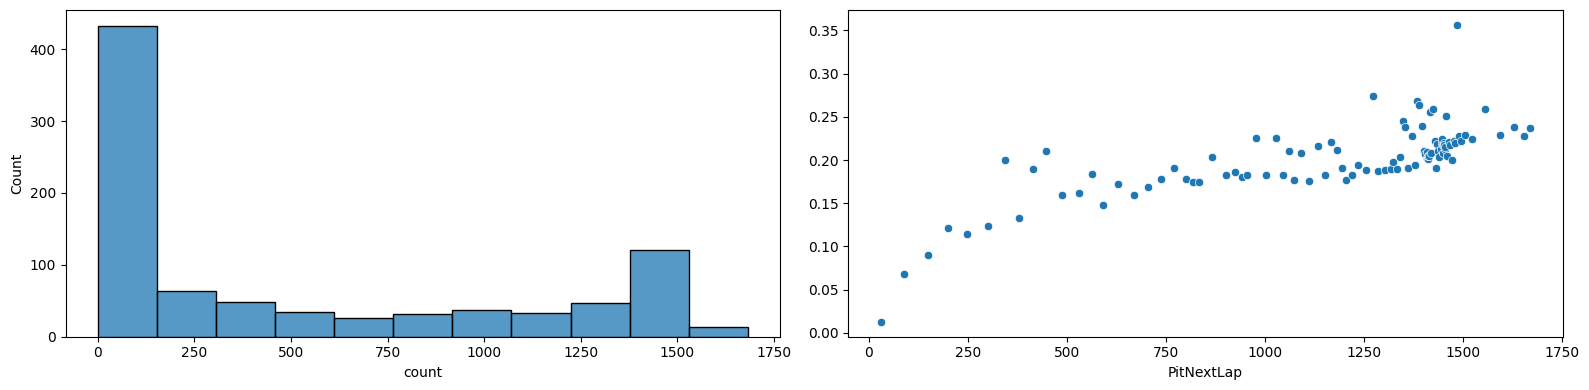

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (16, 4))
sns.histplot(
    df_train['Driver'].value_counts(), ax = axes[0]
)
df_train.groupby(
    pd.qcut(df_train.groupby('Driver')[y].transform('size'), np.arange(0, 101) / 100)
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, ax = axes[1])
)
plt.tight_layout()
plt.show()

In [39]:
df_train['Compound'].value_counts()

Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

In [40]:
pd.crosstab(index = df_train['Compound'], columns = df_train[y], normalize = 'index')

PitNextLap,0,1
Compound,,
HARD,0.672463,0.327537
MEDIUM,0.898869,0.101131
INTERMEDIATE,0.847716,0.152284
SOFT,0.806525,0.193475
WET,0.974908,0.025092


In [41]:
df_train['PitStop'].value_counts(normalize=True)

PitStop
0    0.863882
1    0.136118
Name: proportion, dtype: float64

In [42]:
pd.crosstab(index = df_train['PitStop'], columns = df_train[y], normalize = 'index')

PitNextLap,0,1
PitStop,,
0,0.808715,0.191285
1,0.752171,0.247829


In [43]:
df_train['Race'].value_counts()

Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand Prix           15383
Qatar Grand Prix             13817
Japanese Grand Prix          12891
Las Vegas Grand Prix         12479
Azerbaijan Grand Prix        12126
São Paulo Grand Prix         11497
Belgian Grand Prix            9002
Chinese Grand Prix            7311
French Grand Prix             3185
Name: count, dtype: int64

In [44]:
pd.crosstab(index=df_train['Race'], columns=df_train[y], normalize = 'index')

PitNextLap,0,1
Race,,
Canadian Grand Prix,0.846143,0.153857
Dutch Grand Prix,0.823931,0.176069
Austrian Grand Prix,0.811949,0.188051
Pre-Season Testing,0.853459,0.146541
Azerbaijan Grand Prix,0.785420,0.214580
Saudi Arabian Grand Prix,0.772569,0.227431
Belgian Grand Prix,0.719618,0.280382
United States Grand Prix,0.885952,0.114048
Italian Grand Prix,0.868037,0.131963


In [45]:
pd.Series({i: ce(i) for i in X_bin + X_nom}, name = 'ce').sort_values()

Compound    0.463651
Race        0.481635
Driver      0.489311
PitStop     0.497862
Name: ce, dtype: float64

# Numeric Variables

In [46]:
df_train['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [47]:
pd.crosstab(index = df_train['Year'], columns = df_train[y], normalize = 'index')

PitNextLap,0,1
Year,,
2022,0.733495,0.266505
2023,0.990393,0.009607
2024,0.704681,0.295319
2025,0.715611,0.284389


In [48]:
df_train['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [49]:
pd.crosstab(index = df_train['Year'], columns = df_train[y])

PitNextLap,0,1
Year,,
2022,60872,22117
2023,134839,1308
2024,89572,37538
2025,66476,26418


- 2023 년도의 PitNextLap은 대부분 0 이다. Year가 2023년인 여부와 관련이 큰 Feature의 영향이 있을 수 있다.

In [57]:
df_train['Stint'].value_counts()

Stint
1    216288
2    129536
3     69238
4     18903
5      4281
6       728
7       116
8        50
Name: count, dtype: int64

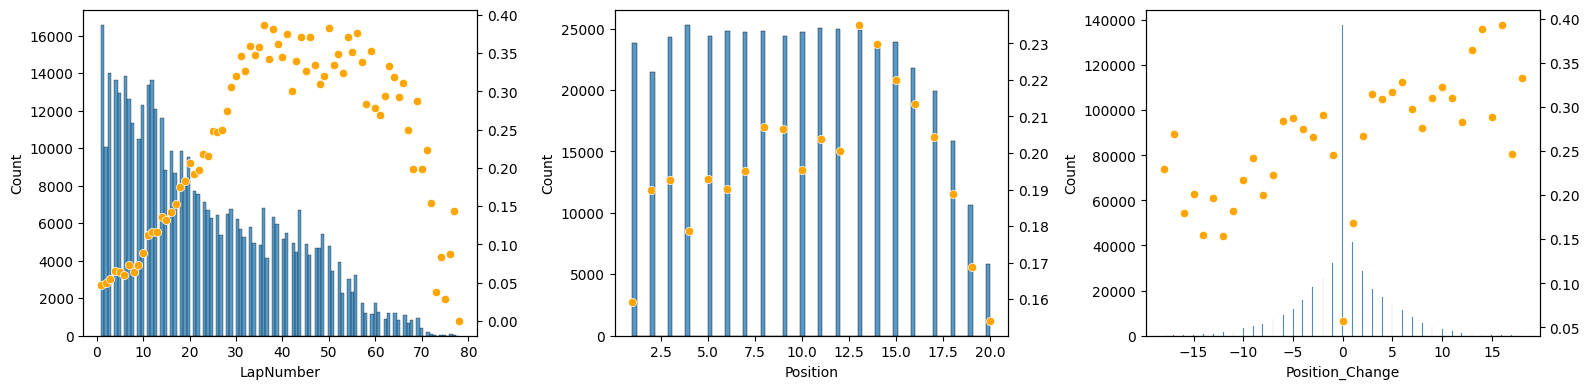

In [58]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
sns.histplot(df_train['LapNumber'], ax=axes[0])
df_train.groupby('LapNumber')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[0].twinx())
)
sns.histplot(df_train['Position'], ax=axes[1])
df_train.groupby('Position')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[1].twinx())
)
sns.histplot(df_train['Position_Change'], ax=axes[2])
df_train.groupby('Position_Change')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[2].twinx())
)
plt.tight_layout()
plt.show()

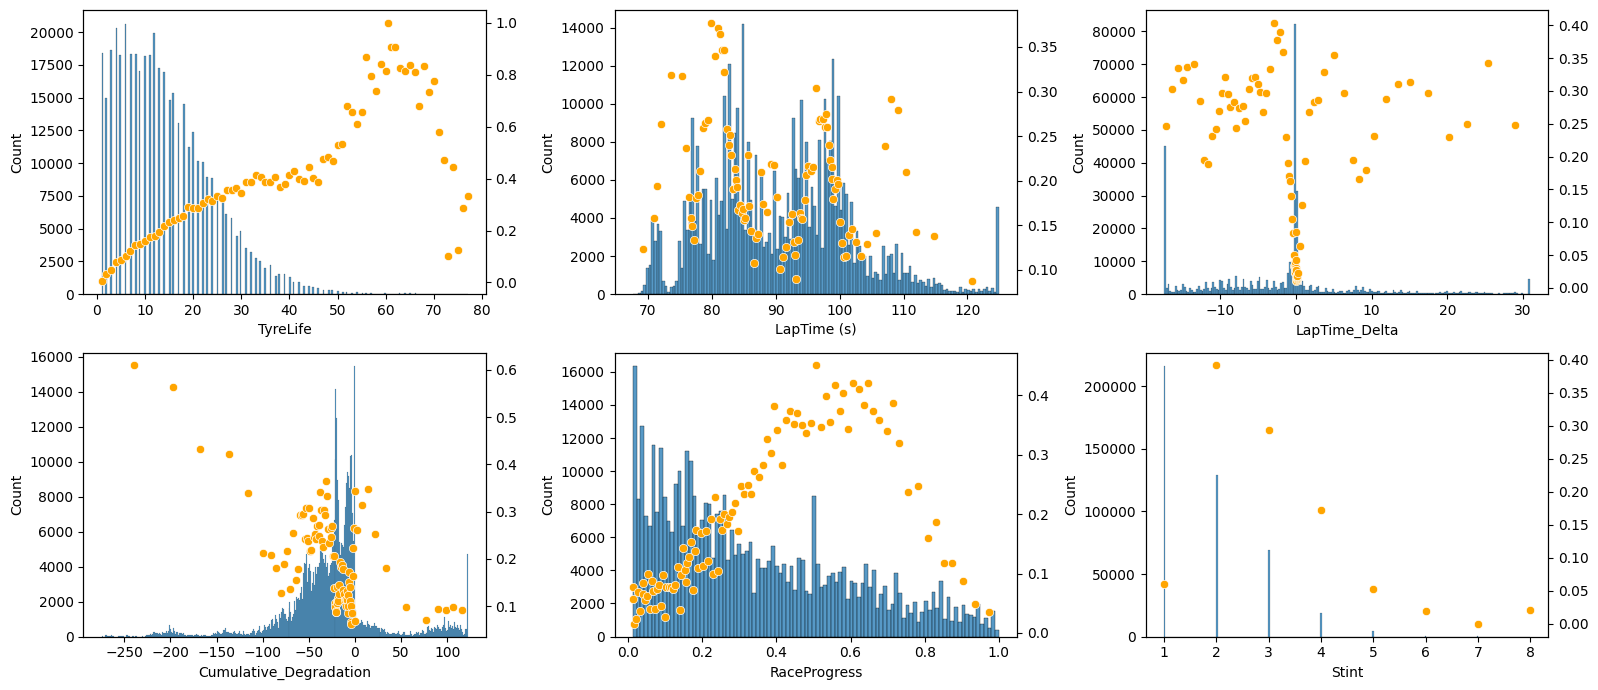

In [59]:
fig, axes = plt.subplots(2, 3, figsize = (16, 7))
axes = axes.flatten()
ax = axes[0]
sns.histplot(df_train['TyreLife'], ax=ax)
df_train.groupby('TyreLife')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=ax.twinx())
)
ax = axes[1]
v = df_train['LapTime (s)'].pipe(lambda x: x.clip(*x.quantile([0, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[2]
v = df_train['LapTime_Delta'].pipe(lambda x: x.clip(*x.quantile([0.1, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[3]
v = df_train['Cumulative_Degradation'].pipe(lambda x: x.clip(*x.quantile([0.0, 0.99])))
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[4]
v = df_train['RaceProgress']
sns.histplot(v, ax=ax)
df_train.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[5]
v = df_train['Stint']
sns.histplot(v, ax=ax)
df_train.groupby('Stint')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax = ax.twinx())
)
plt.tight_layout()
plt.show()

# Year != 2023

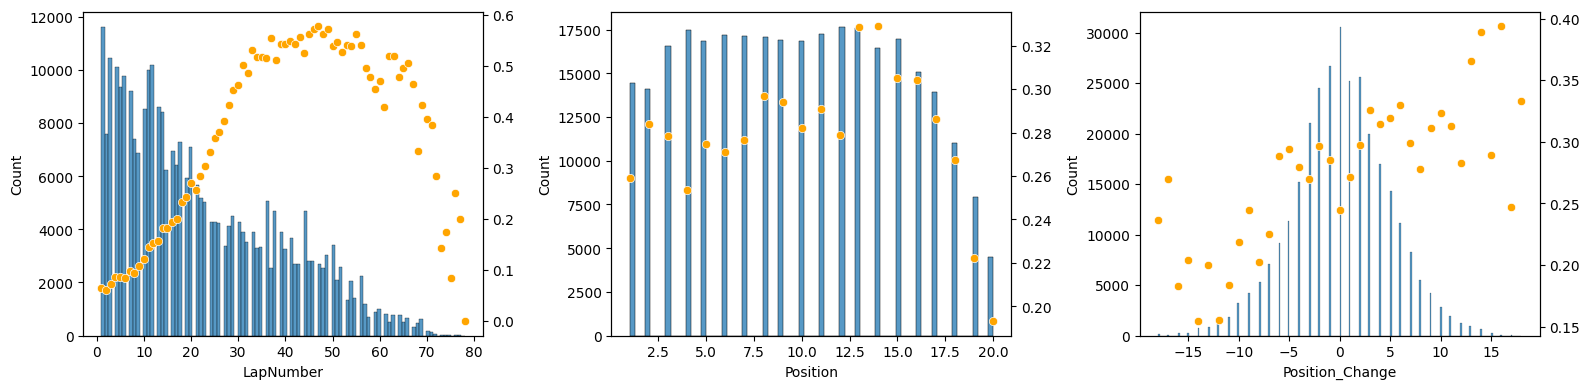

In [60]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
df_train_sub = df_train.loc[df_train['Year'] != 2023]
sns.histplot(df_train_sub['LapNumber'], ax=axes[0])
df_train_sub.groupby('LapNumber')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[0].twinx())
)
sns.histplot(df_train_sub['Position'], ax=axes[1])
df_train_sub.groupby('Position')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[1].twinx())
)
sns.histplot(df_train_sub['Position_Change'], ax=axes[2])
df_train_sub.groupby('Position_Change')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[2].twinx())
)
plt.tight_layout()
plt.show()

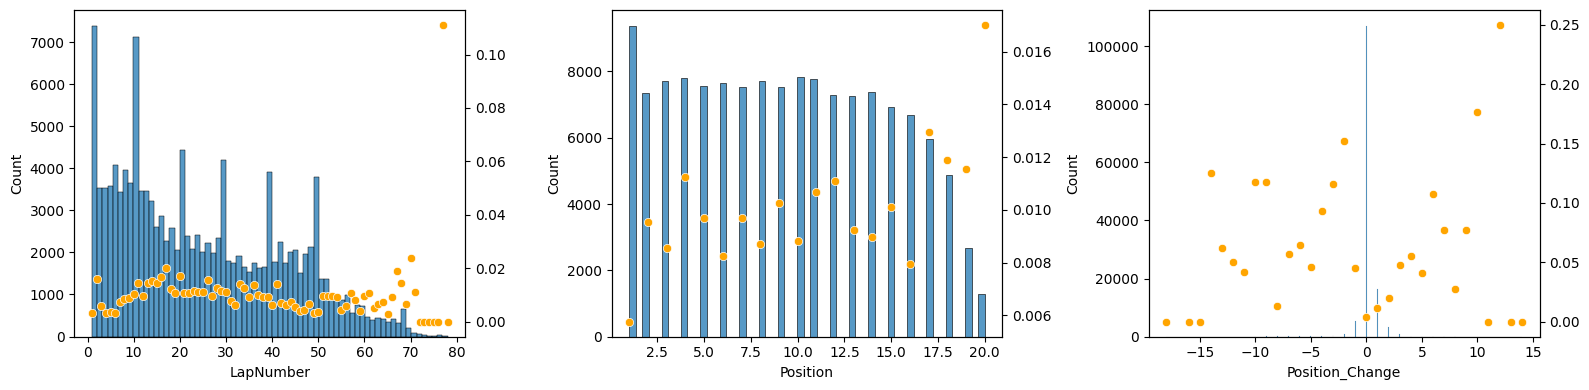

In [61]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
df_train_sub = df_train.loc[df_train['Year'] == 2023]
sns.histplot(df_train_sub['LapNumber'], ax=axes[0])
df_train_sub.groupby('LapNumber')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[0].twinx())
)
sns.histplot(df_train_sub['Position'], ax=axes[1])
df_train_sub.groupby('Position')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[1].twinx())
)
sns.histplot(df_train_sub['Position_Change'], ax=axes[2])
df_train_sub.groupby('Position_Change')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=axes[2].twinx())
)
plt.tight_layout()
plt.show()

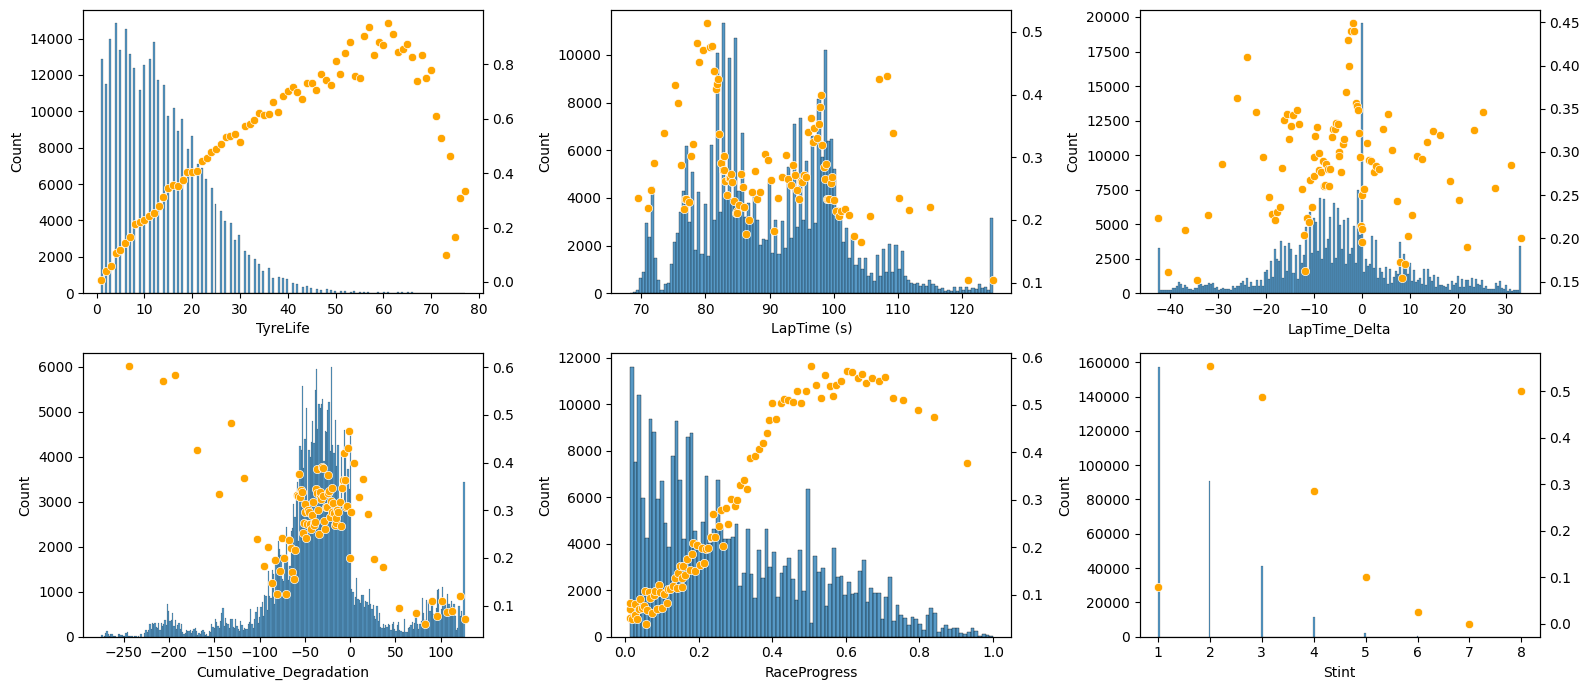

In [54]:
fig, axes = plt.subplots(2, 3, figsize = (16, 7))
axes = axes.flatten()
ax = axes[0]
df_train_sub = df_train.loc[df_train['Year'] != 2023]
sns.histplot(df_train_sub['TyreLife'], ax=ax)
df_train_sub.groupby('TyreLife')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=ax.twinx())
)
ax = axes[1]
v = df_train_sub['LapTime (s)'].pipe(lambda x: x.clip(*x.quantile([0, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[2]
v = df_train_sub['LapTime_Delta'].pipe(lambda x: x.clip(*x.quantile([0.01, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[3]
v = df_train_sub['Cumulative_Degradation'].pipe(lambda x: x.clip(*x.quantile([0.0, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[4]
v = df_train_sub['RaceProgress']
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[5]
v = df_train_sub['Stint']
sns.histplot(v, ax=ax)
df_train_sub.groupby('Stint')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax = ax.twinx())
)
plt.tight_layout()
plt.show()

In [63]:
df_train.groupby("Year")['LapTime_Delta'].mean()

Year
2022   -5.311211
2023   -0.492364
2024   -5.926877
2025   -4.245746
Name: LapTime_Delta, dtype: float32

In [64]:
df_train.groupby("Year")['PitStop'].mean()

Year
2022    0.186543
2023    0.012376
2024    0.192219
2025    0.195664
Name: PitStop, dtype: float64

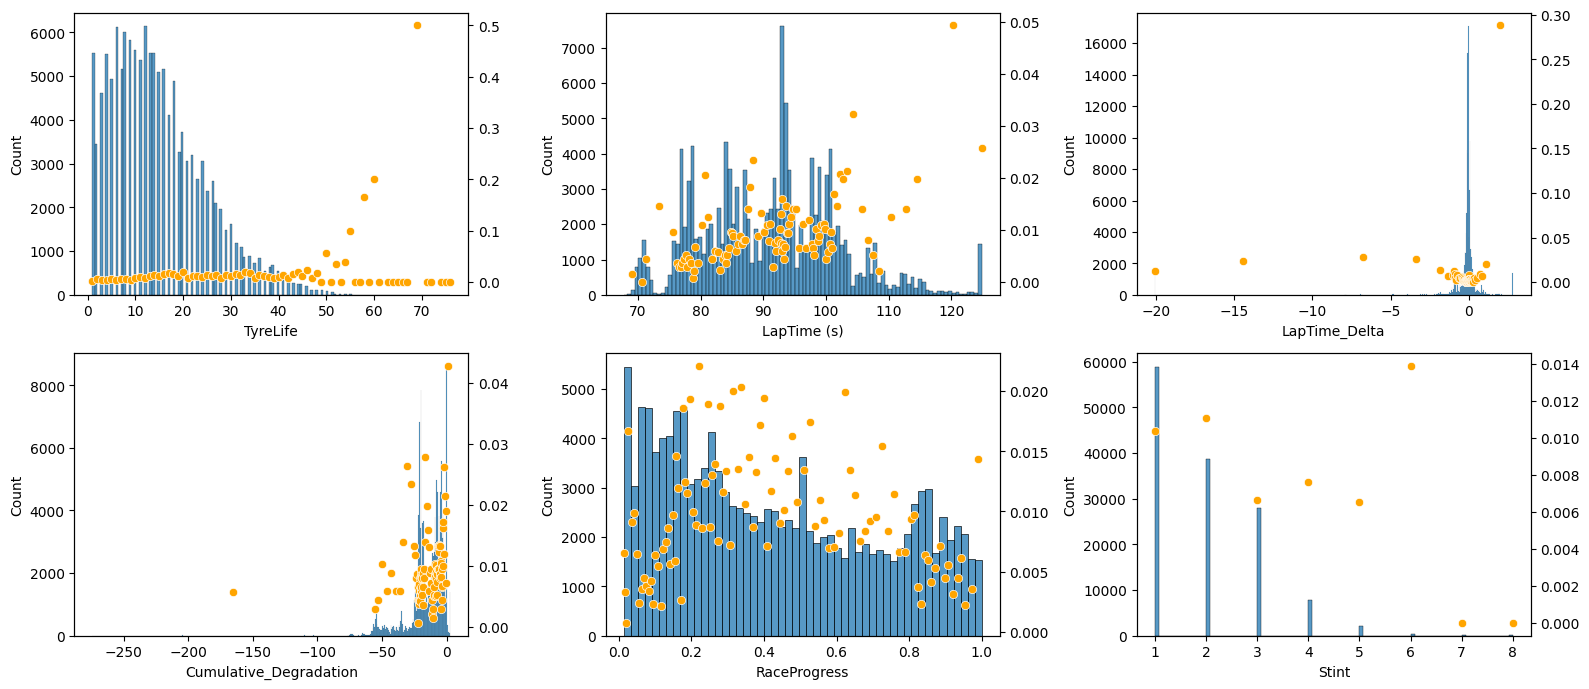

In [55]:
fig, axes = plt.subplots(2, 3, figsize = (16, 7))
axes = axes.flatten()
ax = axes[0]
df_train_sub = df_train.loc[df_train['Year'] == 2023]
sns.histplot(df_train_sub['TyreLife'], ax=ax)
df_train_sub.groupby('TyreLife')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax=ax.twinx())
)
ax = axes[1]
v = df_train_sub['LapTime (s)'].pipe(lambda x: x.clip(*x.quantile([0, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[2]
v = df_train_sub['LapTime_Delta'].pipe(lambda x: x.clip(*x.quantile([0.01, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[3]
v = df_train_sub['Cumulative_Degradation'].pipe(lambda x: x.clip(*x.quantile([0.0, 0.99])))
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[4]
v = df_train_sub['RaceProgress']
sns.histplot(v, ax=ax)
df_train_sub.groupby(
    pd.qcut(v, np.arange(0, 101) / 100, duplicates = 'drop')
)[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
)
ax = axes[5]
v = df_train_sub['Stint']
sns.histplot(v, ax=ax)
df_train_sub.groupby('Stint')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax = ax.twinx())
)
plt.tight_layout()
plt.show()

In [66]:
df_y2023 = df_train.assign(
    y2023 = lambda x: x['Year'] == 2023
).drop(columns = ['Year'])

In [67]:
ss = ShuffleSplit(n_splits = 1, random_state = 123)
X = [i for i in X_all if i not in ['Year']]
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_y2023[X], df_y2023['y2023'], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.62688446]),
 'score_time': array([0.02025366]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.99759413]),
 'train_score': array([0.99954504])}

In [68]:
pd.Series(result['estimator'][0].feature_importances_, index = X).sort_values(ascending = False)

LapTime_Delta             0.482689
Position_Change           0.149228
PitStop                   0.127620
Cumulative_Degradation    0.070924
LapNumber                 0.032158
Stint                     0.030982
RaceProgress              0.029289
Race                      0.025427
Compound                  0.018650
Driver                    0.014251
TyreLife                  0.010145
LapTime (s)               0.006254
Position                  0.002383
dtype: float32

In [69]:
ss = ShuffleSplit(n_splits = 1, random_state = 123)
X = [i for i in X_all if i not in ['Year']]

roc = list()
v = list()

while len(X) > 0:
    result = cross_validate(
        xgb.XGBClassifier(enable_categorical = True), df_y2023[X], df_y2023['y2023'], cv = ss, scoring = 'roc_auc', return_train_score = True, 
        return_estimator = True
    )
    imp = pd.Series(result['estimator'][0].feature_importances_, index = X).sort_values(ascending = False)
    v.append(imp.index[0])
    roc.append(result['test_score'])
    X = imp.index[1:].tolist()

In [70]:
pd.Series([i[0] for i in roc], index = v)

LapTime_Delta             0.997594
Position_Change           0.996897
PitStop                   0.995817
Cumulative_Degradation    0.995295
LapNumber                 0.989415
Stint                     0.972012
Race                      0.957967
RaceProgress              0.923517
Compound                  0.778783
Driver                    0.734781
LapTime (s)               0.708015
TyreLife                  0.556806
Position                  0.523076
dtype: float64

In [71]:
X = X_all
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_train[X], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.61542964]),
 'score_time': array([0.02107549]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.93869927]),
 'train_score': array([0.97206622])}

In [72]:
pd.Series(result['estimator'][0].feature_importances_, index = X).sort_values(ascending = False)

Year                      0.402015
Stint                     0.342858
TyreLife                  0.072587
PitStop                   0.044842
LapTime_Delta             0.023555
Race                      0.021919
Compound                  0.018829
Driver                    0.017757
RaceProgress              0.016667
LapNumber                 0.011752
Position_Change           0.010651
Position                  0.007085
Cumulative_Degradation    0.006073
LapTime (s)               0.003412
dtype: float32

In [73]:
X = [i for i in X_all if i != 'Year']
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True), df_train[X], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.64158201]),
 'score_time': array([0.01958013]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.93323569]),
 'train_score': array([0.96824326])}

In [74]:
pd.Series(result['estimator'][0].feature_importances_, index = X).sort_values(ascending = False)

Stint                     0.456276
LapTime_Delta             0.140283
TyreLife                  0.115062
Position_Change           0.059774
PitStop                   0.041271
Compound                  0.033400
RaceProgress              0.033344
Race                      0.032680
Driver                    0.027439
LapNumber                 0.026774
Cumulative_Degradation    0.016709
Position                  0.011992
LapTime (s)               0.004995
dtype: float32

In [75]:
df_train_sub = df_train.loc[df_train['Year'] == 2023]
X = [i for i in X_all if i != 'Year']
result = cross_validate(
    xgb.XGBClassifier(enable_categorical = True, n_estimators = 100, learning_rate = 0.03), df_train_sub[X], df_train_sub[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.29655313]),
 'score_time': array([0.00963569]),
 'estimator': [XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=True, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=0.03, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=100,
                n_jobs=None, num_parallel_tree=None, ...)],
 'test_score': array([0.91487443]),
 'train_score': array([0.97700959])}

In [76]:
pd.Series(result['estimator'][0].feature_importances_, index = X).sort_values(ascending = False)

LapTime_Delta             0.527328
Position_Change           0.095246
Driver                    0.083593
TyreLife                  0.072088
Race                      0.037213
RaceProgress              0.030891
LapTime (s)               0.027757
PitStop                   0.023590
Stint                     0.021737
Cumulative_Degradation    0.021349
LapNumber                 0.020685
Compound                  0.020056
Position                  0.018465
dtype: float32

- Year 가 2023일 때는 target의 분포를 왜곡시켜 놓았다. Year가 주는 정보는 생각보다 미비할 수 있다

- Year가 2023 일 때만 놓아도, Year 이외에도 나머지 속성으로도 상당한 분리력이 있다.

- Year 포함, 제외해도 영향은 분리력에 있어 영향은 그리 크지 않아 보인다. 

In [77]:
df_train.groupby(y)['LapTime_Delta'].agg(['mean', 'std'])

,mean,std
PitNextLap,,
0,-3.661698,47.788967
1,-4.206182,22.622166


In [78]:
df_train.groupby(y)['Position_Change'].agg(['mean', 'std'])

,mean,std
PitNextLap,,
0,0.009219,3.824492
1,0.473192,4.650608


In [79]:
df_train[X_cont + X_int].corr().stack().rename('corr').reset_index().query('level_0 < level_1').assign(
    corr_a=lambda x: x['corr'].abs()
) .sort_values('corr_a', ascending  = False).iloc[:25]

,level_0,level_1,corr,corr_a
64,LapNumber,RaceProgress,0.964539,0.964539
67,LapNumber,Stint,0.724390,0.724390
47,RaceProgress,Stint,0.710020,0.710020
60,LapNumber,TyreLife,0.648408,0.648408
40,RaceProgress,TyreLife,0.622660,0.622660
89,Position,Position_Change,-0.316446,0.316446
31,Cumulative_Degradation,LapTime (s),0.205705,0.205705
36,Cumulative_Degradation,LapNumber,-0.173135,0.173135
70,Stint,TyreLife,0.157733,0.157733
87,Position,Stint,0.151200,0.151200


# Feature Importance

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

In [81]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race']),
    ('pt', 'passthrough', ['LapNumber', 'Stint', 'Position', 'Position_Change'] + X_cont)
])
clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = 3))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.80979681]),
 'score_time': array([0.02320123]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change',
                                                     'TyreLife', 'LapTime (s)',
                                                     'LapTime_Delta',
                                                     'Cumulative_Degradation',
                                                     'RaceProgress'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_depth=3))])],
 'test_score': array([0.8499004])

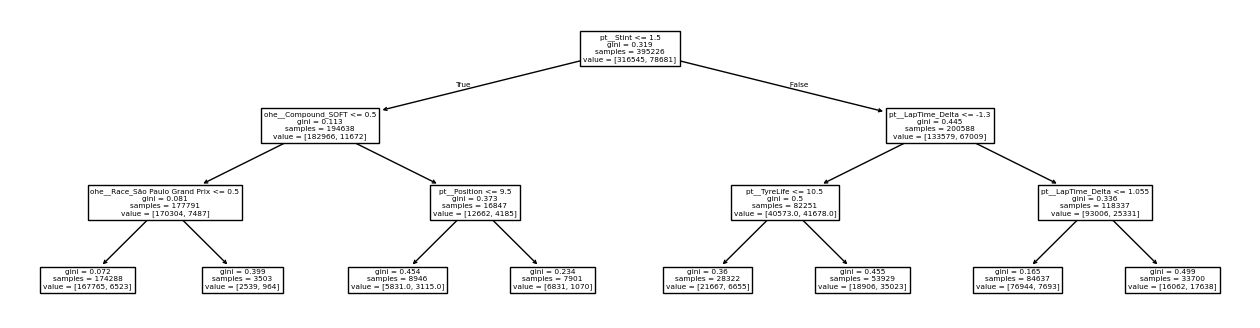

In [82]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 4))
plot_tree(result['estimator'][0][1], feature_names = result['estimator'][0][0].get_feature_names_out())
plt.show()

In [83]:
auc_test, auc_train = dict(), dict()
for i in range(3, 15):
    clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = i))
    result = cross_validate(
        clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
        return_estimator = True
    )
    auc_test[i] = result['test_score'][0]
    auc_train[i] = result['train_score'][0]
auc_test, auc_train = pd.Series(auc_test), pd.Series(auc_train)

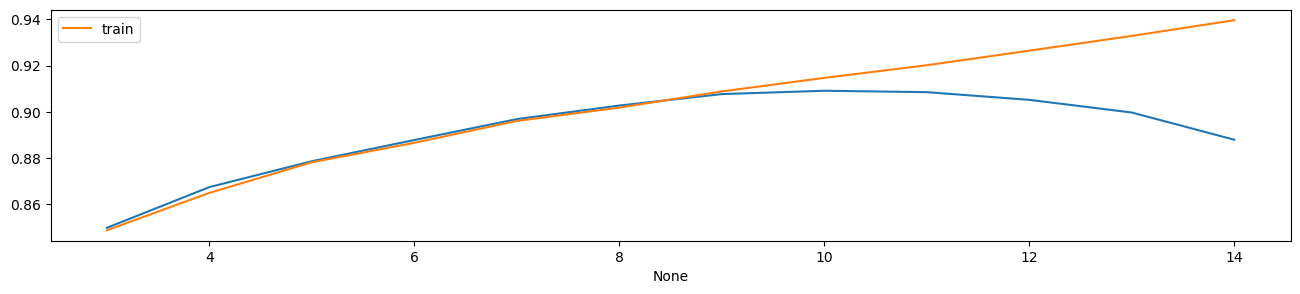

In [84]:
plt.figure(figsize=(16, 3))
sns.lineplot(x = auc_test.index, y = auc_test.values)
sns.lineplot(x = auc_train.index, y = auc_train.values, label = 'train')
plt.show()

In [85]:
auc_test.max(), auc_test.idxmax(), auc_train.loc[10]

(np.float64(0.9090927214163123), 10, np.float64(0.9146533265305196))

In [86]:
clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 2048, min_samples_leaf = 128))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([11.39395356]),
 'score_time': array([0.03262234]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change',
                                                     'TyreLife', 'LapTime (s)',
                                                     'LapTime_Delta',
                                                     'Cumulative_Degradation',
                                                     'RaceProgress'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=2048,
                             

In [87]:
pd.Series(
    result['estimator'][0][1].feature_importances_, index = result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False).iloc[:20]

pt__LapTime_Delta                      0.307587
pt__Stint                              0.249495
pt__TyreLife                           0.218469
pt__RaceProgress                       0.047926
pt__Position_Change                    0.043567
pt__Cumulative_Degradation             0.024237
ohe__Compound_SOFT                     0.021353
pt__Position                           0.015821
pt__LapTime (s)                        0.012812
ohe__Race_Mexico City Grand Prix       0.010570
ohe__Race_São Paulo Grand Prix         0.006536
pt__LapNumber                          0.006177
ohe__Race_Monaco Grand Prix            0.005147
ohe__Race_Emilia Romagna Grand Prix    0.003732
ohe__Race_Chinese Grand Prix           0.003689
ohe__Race_Belgian Grand Prix           0.002955
ohe__Race_Pre-Season Testing           0.002677
ohe__Compound_HARD                     0.002373
ohe__Race_Saudi Arabian Grand Prix     0.002360
ohe__Race_Miami Grand Prix             0.001916
dtype: float64

In [88]:
ct = ColumnTransformer([
    ('pt', 'passthrough', ['LapTime_Delta'])
])

clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 1024))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.31805897]),
 'score_time': array([0.00846791]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('pt', 'passthrough',
                                                    ['LapTime_Delta'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=1024))])],
 'test_score': array([0.71010235]),
 'train_score': array([0.73384644])}

In [89]:
roc_auc_score(
    df_train[y], -df_train['LapTime_Delta']
)

0.5661637585150627

In [90]:
tgt = TargetEncoder(target_type = 'binary')
roc_auc_score(
    df_train[y], tgt.fit_transform(df_train[['LapTime_Delta']], df_train[y])
)

0.6675640867882171

In [107]:
df_train['LapTime_Delta'].nunique()

44485

In [91]:
kbin = KBinsDiscretizer(n_bins = 30, encode = 'ordinal', strategy = 'quantile', quantile_method  = 'linear')
kbin_tgt = make_pipeline(kbin, TargetEncoder(target_type = 'binary'))
roc_auc_score(
    df_train[y], kbin_tgt.fit_transform(df_train[['LapTime_Delta']], df_train[y])
)

0.7027989494535792

In [92]:
ct = ColumnTransformer([
    ('pt', 'passthrough', ['Stint'])
])

clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 1024))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.03191066]),
 'score_time': array([0.00598145]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('pt', 'passthrough',
                                                    ['Stint'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=1024))])],
 'test_score': array([0.74738491]),
 'train_score': array([0.74640872])}

In [93]:
roc_auc_score(
    df_train[y], df_train['Stint']
)

0.6839998159245791

In [94]:
tgt = TargetEncoder(target_type = 'binary')
roc_auc_score(
    df_train[y], tgt.fit_transform(df_train[['Stint']], df_train[y])
)

0.7457011290418603

In [95]:
ct = ColumnTransformer([
    ('pt', 'passthrough', ['TyreLife'])
])

clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 1024))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.05551529]),
 'score_time': array([0.00659752]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('pt', 'passthrough',
                                                    ['TyreLife'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=1024))])],
 'test_score': array([0.70476302]),
 'train_score': array([0.69852798])}

In [96]:
roc_auc_score(
    df_train[y], df_train['TyreLife']
)

0.6989480488545307

In [106]:
from sklearn.preprocessing import TargetEncoder, KBinsDiscretizer
tgt = TargetEncoder(target_type = 'binary')
roc_auc_score(
    df_train[y], tgt.fit_transform(df_train[['TyreLife']], df_train[y])
)

0.698658027965147

In [105]:
df_train['TyreLife'].nunique()

78

In [109]:
ct = ColumnTransformer([
    ('pt', 'passthrough', ['LapTime_Delta', 'Stint', 'TyreLife'])
])
clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 2048, min_samples_leaf = 128))
result = cross_validate(
    clf_dt, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.45295882]),
 'score_time': array([0.00987935]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('pt', 'passthrough',
                                                    ['LapTime_Delta', 'Stint',
                                                     'TyreLife'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=2048,
                                          min_samples_leaf=128))])],
 'test_score': array([0.8781355]),
 'train_score': array([0.89102236])}

In [111]:
from sklearn.linear_model import LogisticRegression
ct = ColumnTransformer([
    ('kbin_tgt', make_pipeline(kbin, TargetEncoder(target_type = 'binary')), ['LapTime_Delta']),
    ('tgt', TargetEncoder(target_type = 'binary'), ['Stint', 'TyreLife'])
])
clf_lr = make_pipeline(ct, LogisticRegression())
result = cross_validate(
    clf_lr, df_train[X_all], df_train[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([0.5537045]),
 'score_time': array([0.03295779]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('kbin_tgt',
                                                    Pipeline(steps=[('kbinsdiscretizer',
                                                                     KBinsDiscretizer(encode='ordinal',
                                                                                      n_bins=15,
                                                                                      quantile_method='linear')),
                                                                    ('targetencoder',
                                                                     TargetEncoder(target_type='binary'))]),
                                                    ['LapTime_Delta']),
                                                   ('tgt',
                                                    TargetEncoder(target_type='binar

In [36]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race']),
    ('pt', 'passthrough', ['LapNumber', 'Stint', 'Position', 'Position_Change'] + X_cont)
])
clf_dt = make_pipeline(ct, DecisionTreeClassifier(max_depth = None, max_leaf_nodes = 2048, min_samples_leaf = 128))
df_train_2023 = df_train.loc[df_train['Year'] != 2023]
result = cross_validate(
    clf_dt, df_train_2023[X_all], df_train_2023[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

{'fit_time': array([7.51009011]),
 'score_time': array([0.02080059]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change',
                                                     'TyreLife', 'LapTime (s)',
                                                     'LapTime_Delta',
                                                     'Cumulative_Degradation',
                                                     'RaceProgress'])])),
                  ('decisiontreeclassifier',
                   DecisionTreeClassifier(max_leaf_nodes=2048,
                              

In [37]:
pd.Series(
    result['estimator'][0][1].feature_importances_, index = result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False).iloc[:20]

pt__Stint                              0.522517
pt__TyreLife                           0.248694
pt__RaceProgress                       0.046889
ohe__Compound_SOFT                     0.033570
pt__Position                           0.021418
pt__LapTime (s)                        0.017157
pt__LapTime_Delta                      0.016850
pt__LapNumber                          0.015881
ohe__Race_Mexico City Grand Prix       0.013724
pt__Cumulative_Degradation             0.009952
ohe__Race_São Paulo Grand Prix         0.007238
ohe__Compound_INTERMEDIATE             0.005781
ohe__Race_Monaco Grand Prix            0.005609
ohe__Compound_HARD                     0.005007
ohe__Race_Saudi Arabian Grand Prix     0.003602
ohe__Race_Emilia Romagna Grand Prix    0.003148
ohe__Race_Chinese Grand Prix           0.003021
pt__Position_Change                    0.002455
ohe__Race_Miami Grand Prix             0.001946
ohe__Race_Belgian Grand Prix           0.001844
dtype: float64

- LapTime_Delta는 2023년을 제외한 데이터에서 구분에 있어 그리 큰 도움을 주는 것으로 보이지 않는다. 분포상에서도 연관성이 크다고 볼 수 없다.


In [38]:
df_train_sub = df_train.loc[df_train['Year'] == 2023]
X = [i for i in X_all if i != 'Year']
clf_xgb = xgb.XGBClassifier(enable_categorical = True, n_estimators = 100, learning_rate = 0.03)
clf_xgb.fit(df_train_sub[X], df_train_sub[y])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [42]:
from sklearn.metrics import roc_auc_score
df_train_sub = df_train.loc[df_train['Year'] != 2023]
roc_auc_score(
    df_train_sub[y], clf_xgb.predict_proba(df_train_sub[X])[:, 1]
)

0.6109674791003032

In [43]:
df_train_sub = df_train.loc[df_train['Year'] != 2023]
X = [i for i in X_all if i != 'Year']
clf_xgb = xgb.XGBClassifier(enable_categorical = True, n_estimators = 100, learning_rate = 0.03)
clf_xgb.fit(df_train_sub[X], df_train_sub[y])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [44]:
from sklearn.metrics import roc_auc_score
df_train_sub = df_train.loc[df_train['Year'] == 2023]
roc_auc_score(
    df_train_sub[y], clf_xgb.predict_proba(df_train_sub[X])[:, 1]
)

0.5892309035990889

- LapTime_Delta의 분포를 좀 더 세밀하게 보자.

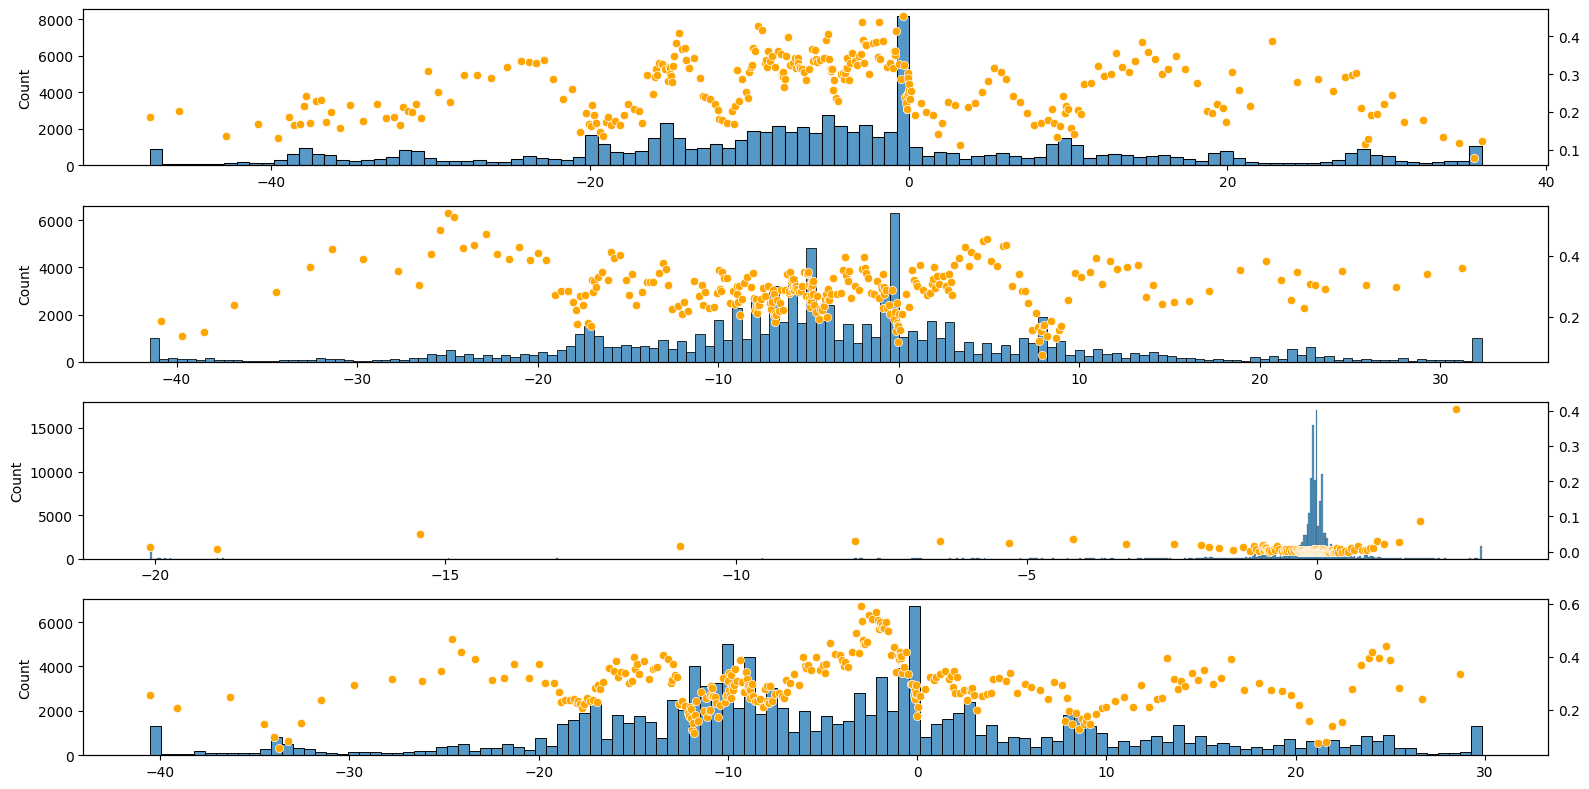

In [60]:
fig, axes = plt.subplots(4, 1, figsize = (16, 8))
for i, ax in zip(df_train['Year'].unique(), axes.flatten()):
    v = df_train.loc[df_train['Year'] == i, 'LapTime_Delta'].pipe(lambda x: x.clip(*x.quantile([0.01, 0.99])))
    sns.histplot(x=v.values, ax=ax)
    df_train.groupby(
        pd.qcut(v, np.arange(0, 301) / 300, duplicates = 'drop')
    )[y].mean().pipe(
        lambda x: sns.scatterplot(x = x.index.map(lambda x: (x.left + x.right) / 2), y = x.values, c = 'orange', ax = ax.twinx())
    )
plt.tight_layout()
plt.show()

In [61]:
df_train_sub = df_train.loc[df_train['Year'] == 2023]
roc_auc_score(df_train_sub[y], df_train_sub['LapTime_Delta'])

0.7535649237181785

- LapTime_Delta 는 독립적으로 target과 연관이 있어 보이지 않고, 다른 특성과 서로 연관성이 있어 보인다. 완전히 연관이 없다기 보다는, 어떠한 구간 내에서 비례하는 성질이 있는 것으로 보인다.

- LapTime_Delta를 다른 변수에 의해 얼만큼 설명될 수 있고, 이 때 중요한 변수는 무엇일지 보자.

In [104]:
import lightgbm as lgb
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race']),
    ('pt', 'passthrough', ['LapNumber', 'Stint', 'Position', 'Position_Change', 'PitStop'] + [i for i in X_cont if i != 'LapTime_Delta'])
])
reg_lgb = make_pipeline(ct, lgb.LGBMRegressor(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    reg_lgb, df_train[X_all], df_train[y], cv = ss, scoring = 'r2', return_train_score = True, 
    return_estimator = True
)
result

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'fit_time': array([2.83855391]),
 'score_time': array([0.18106818]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change', 'PitStop',
                                                     'TyreLife', 'LapTime (s)',
                                                     'Cumulative_Degradation',
                                                     'RaceProgress'])])),
                  ('lgbmregressor',
                   LGBMRegressor(learning_rate=0.05, n_estimators=1500,
                                 verbosity=-1))])],
 'test_score': array([0.52451865]),
 

In [105]:
pd.Series(
    result['estimator'][0][1].feature_importances_, result['estimator'][0][0].get_feature_names_out()
).sort_values(ascending = False)

pt__Cumulative_Degradation             7624
pt__LapTime (s)                        5808
pt__TyreLife                           5481
pt__RaceProgress                       5348
pt__Position_Change                    4240
pt__Position                           3561
pt__LapNumber                          3312
pt__Stint                              2096
pt__PitStop                             763
ohe__Compound_HARD                      618
ohe__Compound_MEDIUM                    511
ohe__Compound_SOFT                      461
ohe__Race_Monaco Grand Prix             311
ohe__Race_São Paulo Grand Prix          297
ohe__Race_Spanish Grand Prix            295
ohe__Race_Emilia Romagna Grand Prix     283
ohe__Race_Australian Grand Prix         280
ohe__Race_Bahrain Grand Prix            254
ohe__Race_Canadian Grand Prix           247
ohe__Race_Dutch Grand Prix              241
ohe__Race_Pre-Season Testing            228
ohe__Race_Singapore Grand Prix          223
ohe__Race_Mexico City Grand Prix

In [122]:
df_train.groupby('Race').apply(
    lambda x: (x['LapNumber'] / x['RaceProgress']).round().pipe(
        lambda y: pd.Series((y.mode()[0], (y != y.mode()[0]).mean()), index = ['mode', 'not mode rate'])
    )
)

,mode,not mode rate
Race,,
Canadian Grand Prix,72.0,0.758872
Dutch Grand Prix,72.0,0.549219
Austrian Grand Prix,72.0,0.772841
Pre-Season Testing,52.0,0.702961
Azerbaijan Grand Prix,51.0,0.642669
Saudi Arabian Grand Prix,50.0,0.728839
Belgian Grand Prix,44.0,0.713175
United States Grand Prix,56.0,0.735218
Italian Grand Prix,51.0,0.686411


- 데이터에 노이즈가 내재 되어 있습니다. 이를 잘 처리하는 게 급선무인듯 함

- 데이터간에는 공선성이 있으니, 이를 잘 이용하면 해볼만하지 않을까 싶습니다.

- 원본 데이터에 노이즈가 마찬가지로 있을까요?

In [32]:
df_org.groupby('Race').apply(
    lambda x: (x['LapNumber'] / x['RaceProgress']).round().pipe(
        lambda y: pd.Series((y.mode()[0], (y != y.mode()[0]).mean()), index = ['mode', 'not mode rate'])
    )
)

,mode,not mode rate
Race,,
Abu Dhabi Grand Prix,58.0,0.705320
Australian Grand Prix,72.0,0.735894
Austrian Grand Prix,72.0,0.782707
Azerbaijan Grand Prix,72.0,0.762555
Bahrain Grand Prix,72.0,0.759909
Belgian Grand Prix,44.0,0.748651
British Grand Prix,52.0,0.743373
Canadian Grand Prix,72.0,0.754560
Dutch Grand Prix,72.0,0.520233


- PitStop 할 때의 TyreLife

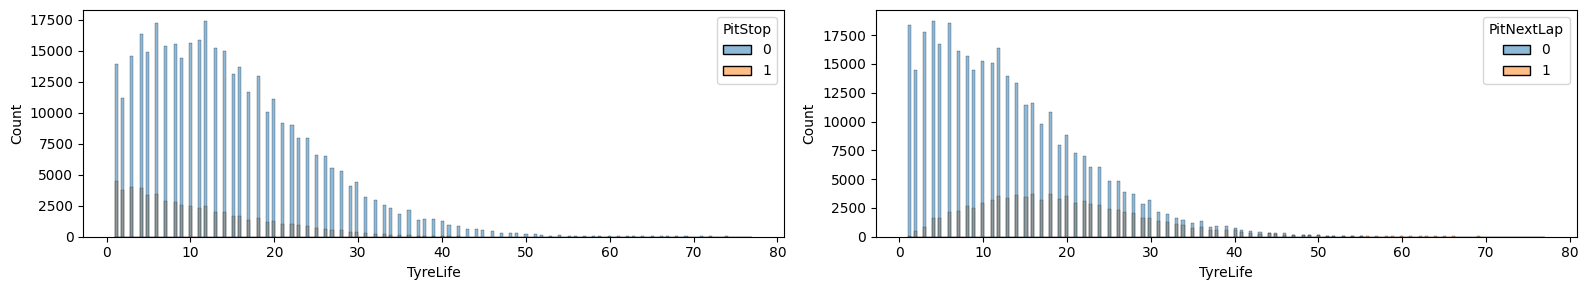

In [33]:
_, axes = plt.subplots(1, 2, figsize = (16, 3))
sns.histplot(data=df_train, x = 'TyreLife', hue = 'PitStop', ax = axes[0])
sns.histplot(data=df_train, x = 'TyreLife', hue = y, ax= axes[1])
plt.tight_layout()
plt.show()

- PitStop 이 1 일 때 PitNextLap 의 비율이 큽니다. 그런데, PitStop 한 다음에 다음에 또하는 경우는 흔한 경우는 아닌데... 데이터에 치우침이 심한듯합니다.

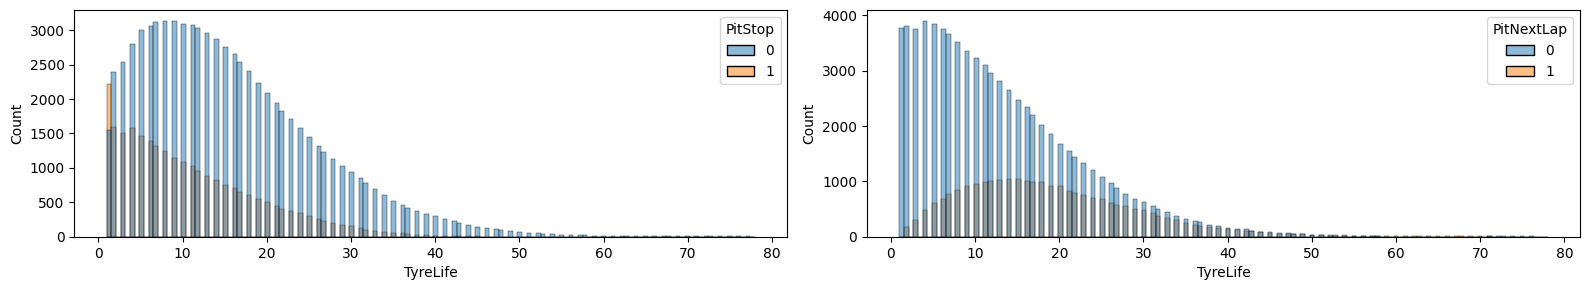

In [34]:
_, axes = plt.subplots(1, 2, figsize = (16, 3))
sns.histplot(data=df_org, x = 'TyreLife', hue = 'PitStop', ax = axes[0])
sns.histplot(data=df_org, x = 'TyreLife', hue = y, ax= axes[1])
plt.tight_layout()
plt.show()

In [35]:
pd.concat([
    df_train.groupby('Race').apply(
        lambda x: (x['LapNumber'] / x['RaceProgress']).round().mode()
    ), df_train.groupby('Race')['LapTime (s)'].mean()
], axis=1)

,0,LapTime (s)
Race,,
Canadian Grand Prix,72.0,82.659767
Dutch Grand Prix,72.0,79.410538
Austrian Grand Prix,72.0,73.508820
Pre-Season Testing,52.0,97.915878
Azerbaijan Grand Prix,51.0,108.982483
Saudi Arabian Grand Prix,50.0,96.060257
Belgian Grand Prix,44.0,113.212112
United States Grand Prix,56.0,102.435707
Italian Grand Prix,51.0,86.926102


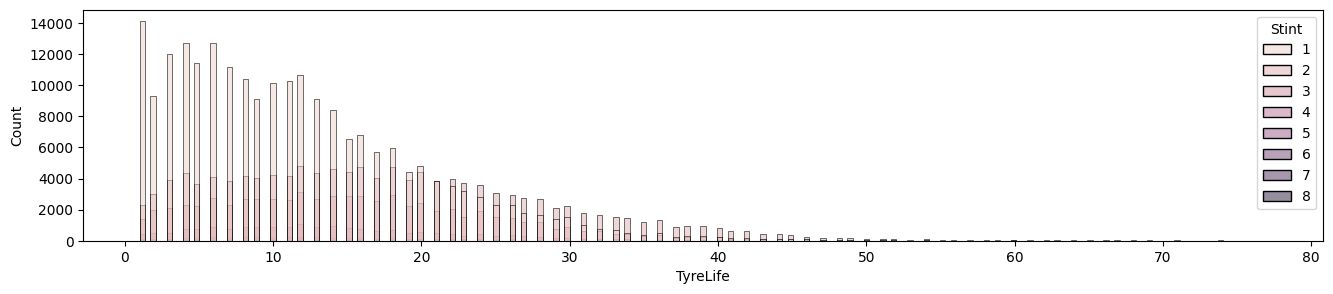

In [36]:
plt.figure(figsize = (16, 3))
sns.histplot(data=df_train, x = 'TyreLife', hue = 'Stint')
plt.show()

In [37]:
(df_train['TyreLife'] > df_train['LapNumber']).mean()

np.float64(0.07596438493418955)

In [38]:
(df_org['TyreLife'] > df_org['LapNumber']).mean()

np.float64(0.05524262363003226)

- TyreLife 에도 분명 이상한 점이 있습니다. 

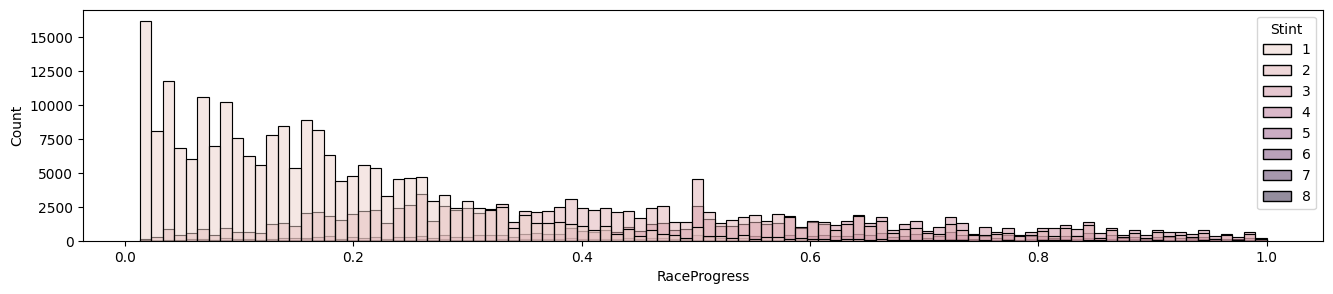

In [39]:
plt.figure(figsize = (16, 3))
sns.histplot(data=df_train, x = 'RaceProgress', hue = 'Stint')
plt.show()

In [40]:
df_train.groupby('Stint')['RaceProgress'].mean()

Stint
1    0.162555
2    0.425414
3    0.606104
4    0.641190
5    0.746961
6    0.793182
7    0.925520
8    0.934322
Name: RaceProgress, dtype: float32

In [41]:
roc_auc_score(
    df_org[y], df_org['Normalized_TyreLife']
)

0.5972229201922081

<Axes: xlabel='Normalized_TyreLife', ylabel='Count'>

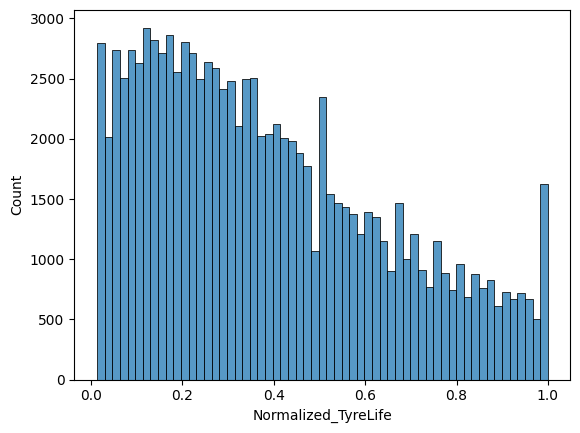

In [42]:
sns.histplot(df_org, x = 'Normalized_TyreLife')

In [47]:
import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race']),
    ('pt', 'passthrough', ['LapNumber', 'Stint', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Normalized_TyreLife'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_org, df_org[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([2.01892972]),
 'score_time': array([0.05900693]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change', 'PitStop',
                                                     'LapTime_Delta',
                                                     'Normalized_TyreLife'])])),
                  ('lgbmclassifier',
                   LGBMClassifier(learning_rate=0.05, n_estimators=1500,
                                  verbosity=-1))])],
 'test_score': array([0.97034336]),
 'train_score': array([0.98863052])}

In [48]:
import lightgbm as lgb
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race']),
    ('pt', 'passthrough', ['LapNumber', 'Stint', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 2300, num_leaves = 31, learning_rate = 0.05))
result = cross_validate(
    clf_lgb, df_org, df_org[y], cv = ss, scoring = 'roc_auc', return_train_score = True, 
    return_estimator = True
)
result

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([2.2155571]),
 'score_time': array([0.0710485]),
 'estimator': [Pipeline(steps=[('columntransformer',
                   ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                    ['Compound', 'Race']),
                                                   ('pt', 'passthrough',
                                                    ['LapNumber', 'Stint',
                                                     'Position',
                                                     'Position_Change', 'PitStop',
                                                     'LapTime_Delta'])])),
                  ('lgbmclassifier',
                   LGBMClassifier(learning_rate=0.05, n_estimators=2300,
                                  verbosity=-1))])],
 'test_score': array([0.96673351]),
 'train_score': array([0.9894239])}

<Axes: xlabel='RaceProgress', ylabel='Count'>

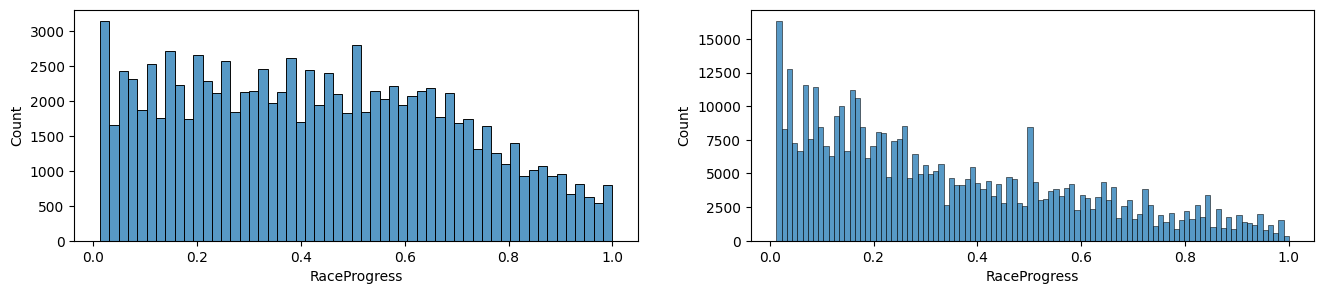

In [49]:
_, axes = plt.subplots(1, 2, figsize=(16, 3))
sns.histplot(df_org, x = 'RaceProgress', ax = axes[0])
sns.histplot(df_train, x = 'RaceProgress', ax = axes[1])

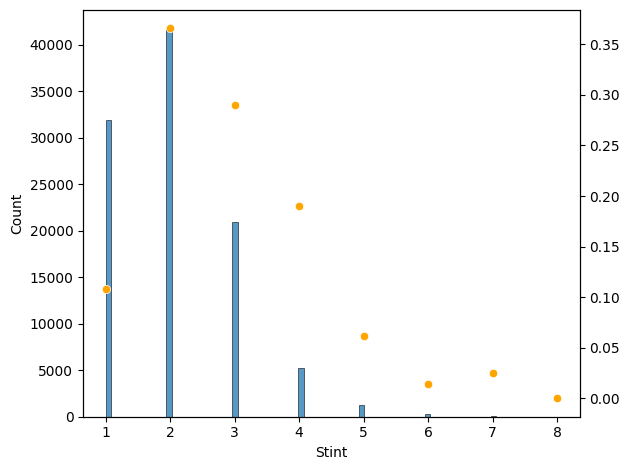

In [50]:
v = df_org['Stint']
ax = plt.gca()
sns.histplot(v, ax=ax)
df_org.groupby('Stint')[y].mean().pipe(
    lambda x: sns.scatterplot(x = x.index, y = x.values, c = 'orange', ax = ax.twinx())
)
plt.tight_layout()
plt.show()

<Axes: xlabel='Cumulative_Degradation', ylabel='Count'>

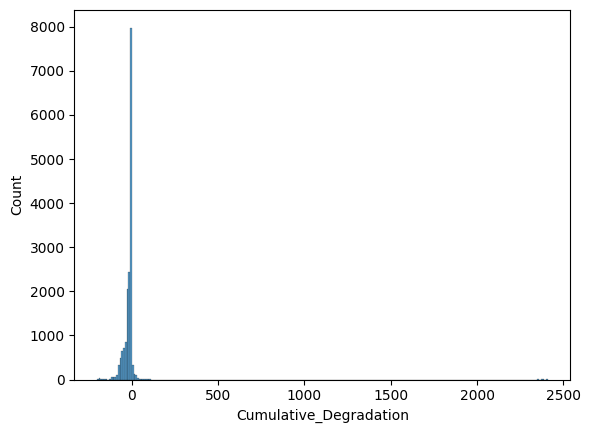

In [51]:
sns.histplot(df_train.loc[df_train['LapNumber'] == 1, 'Cumulative_Degradation'])

In [52]:
(df_train.loc[df_train['LapNumber'] == 1, 'TyreLife'] == 1.0).mean()

np.float64(0.8595844908805411)

In [53]:
df_train.loc[
    (df_train['LapNumber'] == 1) & (df_train['TyreLife'] == 1.0), 'Race'
].value_counts()

Race
United States Grand Prix     961
Pre-Season Testing           882
Dutch Grand Prix             793
Austrian Grand Prix          703
Saudi Arabian Grand Prix     679
Hungarian Grand Prix         648
Australian Grand Prix        644
Miami Grand Prix             642
Canadian Grand Prix          610
Mexico City Grand Prix       575
Japanese Grand Prix          573
Bahrain Grand Prix           563
Singapore Grand Prix         558
Abu Dhabi Grand Prix         551
Qatar Grand Prix             546
British Grand Prix           537
Spanish Grand Prix           513
Italian Grand Prix           489
Emilia Romagna Grand Prix    445
Las Vegas Grand Prix         425
Azerbaijan Grand Prix        403
Chinese Grand Prix           384
Belgian Grand Prix           380
Monaco Grand Prix            376
São Paulo Grand Prix         244
French Grand Prix            109
Name: count, dtype: int64

In [54]:
s_lap_progress = pd.concat([
    df_train.loc[(df_train['LapNumber'] == 1) & (df_train['TyreLife'] == 1.0)], 
    df_test.loc[(df_test['LapNumber'] == 1) & (df_test['TyreLife'] == 1.0)]
]).groupby('Race')['RaceProgress'].apply(lambda x: x.mode()[0])
s_total_lap = (1 / s_lap_progress).round()
pd.concat([s_lap_progress, s_total_lap], axis=1)

,RaceProgress,RaceProgress
Race,,
Canadian Grand Prix,0.013889,72.0
Dutch Grand Prix,0.013889,72.0
Austrian Grand Prix,0.014085,71.0
Pre-Season Testing,0.013889,72.0
Azerbaijan Grand Prix,0.019608,51.0
Saudi Arabian Grand Prix,0.013889,72.0
Belgian Grand Prix,0.013889,72.0
United States Grand Prix,0.013889,72.0
Italian Grand Prix,0.019608,51.0


- LapNumber에 임의로 노이즈가 가해져 있다, Lap Number가 1 보다 작을 경우 강제로 1로 만들었다. 그렇기 때문에 1의 분포가 많다.

- RaceProgress에도 마찬가지로 노이즈가 있을듯하다.

In [55]:
df_train.groupby(['Race', 'LapNumber'])['RaceProgress'].apply(lambda x: x.mode()[0])

Race                 LapNumber
Canadian Grand Prix  1            0.013889
                     2            0.027778
                     3            0.041667
                     4            0.055556
                     5            0.071429
                                    ...   
Qatar Grand Prix     63           0.828947
                     64           0.820513
                     65           0.833333
                     66           0.868421
                     71           1.000000
Name: RaceProgress, Length: 1749, dtype: float32

<Axes: xlabel='TyreLife', ylabel='Count'>

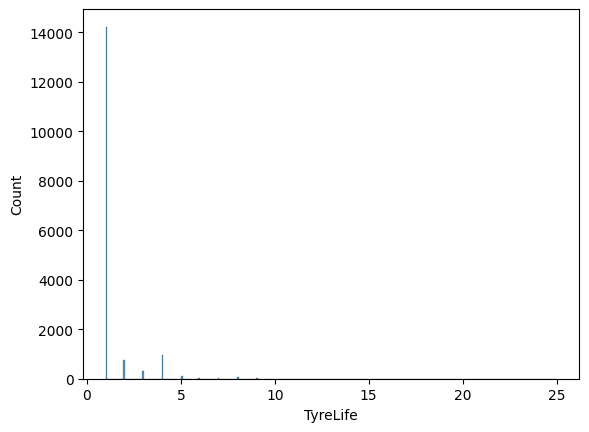

In [56]:
sns.histplot(df_train.loc[df_train['LapNumber'] == 1, 'TyreLife'])

In [57]:
pd.concat([
    df_train.loc[(df_train['Stint'] == 1) & (df_train['TyreLife'] ==1.0)], 
    df_test.loc[(df_test['Stint'] == 1) & (df_test['TyreLife'] ==1.0)]
])['LapNumber'].value_counts()

LapNumber
1     20145
2        39
3         8
25        2
4         2
22        1
5         1
36        1
27        1
Name: count, dtype: int64

- TyreLife 역시 노이즈가 있다.

In [58]:
pd.concat([
    df_train.loc[(df_train['LapNumber'] == 1) & (df_train['TyreLife'] ==1.0)], 
    df_test.loc[(df_test['LapNumber'] == 1) & (df_test['TyreLife'] ==1.0)]
])['Stint'].value_counts(normalize = True)

Stint
1    0.991095
2    0.007134
3    0.001132
4    0.000640
Name: proportion, dtype: float64

- Stint 또한 노이즈가 있다.

In [59]:
df_train['RaceProgress'].nunique()

1618

In [60]:
pd.concat([
    df_train.loc[(df_train['LapNumber'] == 2) & (df_train['TyreLife'] ==1.0)], 
    df_test.loc[(df_test['LapNumber'] == 2) & (df_test['TyreLife'] ==1.0)]
])['Stint'].value_counts()

Stint
2    185
1     39
3      6
6      1
4      1
Name: count, dtype: int64

- Race에도 Noise가 있을 가능성이 크다.

- Stint는 임의로 가산이 되어 2의 분포가 큰 것이다. 1에서 3까지 가산이 된 것 같다.

In [61]:
pd.concat([
    df_train.loc[(df_train['Stint'] == 1) & (df_train['TyreLife'] == 2.0)], 
    df_test.loc[(df_test['Stint'] == 1) & (df_test['TyreLife'] == 2.0)]
])['LapNumber'].value_counts()

LapNumber
2     12199
1      1093
3       140
4        15
5         5
27        5
28        3
7         2
26        2
11        2
33        2
31        1
12        1
9         1
18        1
10        1
30        1
Name: count, dtype: int64

In [62]:
pd.concat([
    df_train.loc[(df_train['Stint'] == 1) & (df_train['TyreLife'] == 2.0)], 
    df_test.loc[(df_test['Stint'] == 1) & (df_test['TyreLife'] == 2.0)]
])['LapNumber'].value_counts()

LapNumber
2     12199
1      1093
3       140
4        15
5         5
27        5
28        3
7         2
26        2
11        2
33        2
31        1
12        1
9         1
18        1
10        1
30        1
Name: count, dtype: int64

In [63]:
pd.concat([
    df_train.loc[(df_train['LapNumber'] > df_train['TyreLife'])], 
    df_test.loc[(df_test['LapNumber'] > df_test['TyreLife'])]
])['Stint'].value_counts()

Stint
2    162252
3     95069
4     24499
5      6108
1      5081
6      1035
7       161
8        70
Name: count, dtype: int64

In [64]:
pd.concat([
    df_train.loc[(df_train['LapNumber'] < df_train['TyreLife'])], 
    df_test.loc[(df_test['LapNumber'] < df_test['TyreLife'])]
])['Stint'].value_counts()

Stint
1    39712
2     6218
3     1556
4      250
5        2
6        1
Name: count, dtype: int64

In [65]:
pd.concat([
    df_train.loc[(df_train['LapNumber'] == df_train['TyreLife'])], 
    df_test.loc[(df_test['LapNumber'] == df_test['TyreLife'])]
])['Stint'].value_counts()

Stint
1    264683
2     16396
4      2206
3      1994
5         9
6         2
7         1
Name: count, dtype: int64

- 노이즈가 독립적으로 가해졌다면, 복구가 가능하지 않을까도 싶다.

In [66]:
X_all_stint = [i for i in X_all if i != 'Stint']

In [67]:
df_stint = pd.concat([
    df_train[X_all_stint + ['Stint']], df_test[X_all_stint + ['Stint']]
]).assign(
    diff = lambda x: x['LapNumber'] - x['TyreLife']
)

In [68]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'diff', 'LapTime (s)', 'RaceProgress', 'TyreLife'])
])
reg_lgb = make_pipeline(ct, lgb.LGBMRegressor(verbosity = -1, n_estimators = 300, num_leaves = 31, learning_rate = 0.03))
cross_validate(
    reg_lgb, df_stint[X_all_stint + ['diff']], df_stint['Stint'],
    scoring = 'r2', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'fit_time': array([1.55873775]),
 'score_time': array([0.087008]),
 'test_score': array([0.8951825]),
 'train_score': array([0.89581765])}

In [69]:
reg_lgb = make_pipeline(ct, lgb.LGBMRegressor(verbosity = -1, n_estimators = 300, num_leaves = 31, learning_rate = 0.03))
reg_lgb.fit(df_stint[X_all_stint + ['diff']], df_stint['Stint'])
df_stint['Stint2'] = reg_lgb.predict(df_stint[X_all_stint + ['diff']])

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [70]:
df_train['Stint2'] = df_stint.loc[df_train.index, 'Stint2']

In [71]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'TyreLife', 'LapTime (s)', 'RaceProgress'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1700, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.58564425]),
 'score_time': array([0.24770188]),
 'test_score': array([0.94886364]),
 'train_score': array([0.9617185])}

In [72]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint2', 'TyreLife', 'LapTime (s)', 'RaceProgress'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.00888348]),
 'score_time': array([0.23416138]),
 'test_score': array([0.94526033]),
 'train_score': array([0.95848726])}

In [73]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'Stint2', 'TyreLife', 'LapTime (s)', 'RaceProgress'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.32717562]),
 'score_time': array([0.21571898]),
 'test_score': array([0.94864504]),
 'train_score': array([0.96126434])}

In [125]:
df_train['Total_Lap'] = df_train['Race'].map(s_total_lap)
df_train['TyreLife2'] = df_train['TyreLife'] / df_train['Total_Lap']
df_train['TyreLife3'] = df_train['RaceProgress'] / df_train['LapNumber'] * df_train['TyreLife']

In [126]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress',
                           'Stint2', 'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.30271006]),
 'score_time': array([0.22307515]),
 'test_score': array([0.94871695]),
 'train_score': array([0.96183261])}

In [103]:
df_train['LapTime_ratio'] = df_train['LapTime_Delta'] / df_train['LapTime (s)']
df_train['LapTime_ratio2'] = df_train['LapTime_Delta'] / df_train.groupby('Race')['LapTime (s)'].transform('mean')
df_train['LapTime_Delta_norm'] = (df_train['LapTime_Delta'] - df_train.groupby(['Race')['LapTime_Delta'].transform('mean')) / df_train.groupby('Race')['LapTime_Delta'].transform('std')

In [105]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 
                           'Stint2', 'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'LapTime_ratio', 'LapTime_ratio2', 'LapTime_Delta_norm'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'LapTime_ratio2', 'LapTime_Delta_norm']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([5.03287745]),
 'score_time': array([0.22067308]),
 'test_score': array([0.94832258]),
 'train_score': array([0.9618558])}

In [78]:
df_train['diff'] = df_train['LapNumber'] - df_train['TyreLife']

In [106]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'diff']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.38466787]),
 'score_time': array([0.20893478]),
 'test_score': array([0.94921284]),
 'train_score': array([0.96123748])}

In [80]:
df_train['RaceProgress2'] = df_train['Race'].map(s_lap_progress) * df_train['LapNumber']

In [81]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'LapTime_ratio', 'diff', 'RaceProgress2'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.53859234]),
 'score_time': array([0.21851301]),
 'test_score': array([0.94938687]),
 'train_score': array([0.9619874])}

In [82]:
df_train['LapNumber2'] = df_train['RaceProgress']  * df_train['Race'].map(s_total_lap)

In [410]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'LapTime_ratio', 'diff', 'LapNumber2'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'LapNumber2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.43842196]),
 'score_time': array([0.21048856]),
 'test_score': array([0.94948793]),
 'train_score': array([0.96190438])}

In [411]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.61381531]),
 'score_time': array([0.20471859]),
 'test_score': array([0.94947284]),
 'train_score': array([0.96200296])}

In [83]:
df_train['diff2'] = df_train['RaceProgress2'] - df_train['RaceProgress']

In [416]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([4.87465978]),
 'score_time': array([0.2125113]),
 'test_score': array([0.94999025]),
 'train_score': array([0.96288795])}

In [107]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([5.03630877]),
 'score_time': array([0.21138573]),
 'test_score': array([0.95096131]),
 'train_score': array([0.96426448])}

In [109]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2', 'Total_Lap']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([3.61756182]),
 'score_time': array([0.21428013]),
 'test_score': array([0.95124974]),
 'train_score': array([0.96428769])}

In [111]:
df_train['TyreLife3_Compound_norm'] = df_train.groupby('Compound')['TyreLife3'].transform(lambda x: (x - x.mean()) / x.std())

In [112]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
cross_validate(
    clf_lgb, df_train[X_all + ['Stint2', 'TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2', 'Total_Lap', 'TyreLife3_Compound_norm']], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([5.55965376]),
 'score_time': array([0.2187736]),
 'test_score': array([0.95135691]),
 'train_score': array([0.96459942])}

In [128]:
df_drv = pd.concat([
    df_train[['Driver', 'Position']], df_test[['Driver', 'Position']]
])

df_drv_stat = df_drv.groupby('Driver')['Position'].agg(['mean', 'count']).rename(columns={'mean': 'Drv_Position_mean', 'count': 'Drv_count'})

In [130]:
df_train = df_train.join(df_drv_stat, on = 'Driver')

In [134]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
X_new = ['TyreLife2', 'TyreLife3', 'LapTime_ratio', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2', 'Total_Lap', 'TyreLife3_Compound_norm',
        'Drv_Position_mean', 'Drv_count']
cross_validate(
    clf_lgb, df_train[X_all + X_new], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([6.05735159]),
 'score_time': array([0.22764635]),
 'test_score': array([0.95175417]),
 'train_score': array([0.96555593])}

In [132]:
df_train['diff_Position'] = df_train['Position'] - df_train['Drv_Position_mean']

In [133]:
ct = ColumnTransformer([
    ('ohe', OneHotEncoder(), ['Compound', 'Race', 'Year']),
    ('pt', 'passthrough', ['LapNumber', 'Position', 'Position_Change', 'PitStop', 'LapTime_Delta', 'Stint', 'RaceProgress', 'Cumulative_Degradation',
                           'TyreLife', 'TyreLife2', 'TyreLife3', 'LapTime (s)', 'diff', 'RaceProgress2', 'LapNumber2',
                           'diff2', 'Total_Lap', 'TyreLife3_Compound_norm', 'Drv_Position_mean', 'Drv_count', 'diff_Position'])
])
clf_lgb = make_pipeline(ct, lgb.LGBMClassifier(verbosity = -1, n_estimators = 1500, num_leaves = 31, learning_rate = 0.05))
X_new = ['TyreLife2', 'TyreLife3', 'diff', 'RaceProgress2', 'LapNumber2', 'diff2', 'Total_Lap', 'TyreLife3_Compound_norm',
        'Drv_Position_mean', 'Drv_count', 'diff_Position']
cross_validate(
    clf_lgb, df_train[X_all + X_new], df_train[y],
    scoring = 'roc_auc', cv = ss, return_train_score = True
)

/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sun9sun9/python312/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'fit_time': array([6.3960371]),
 'score_time': array([0.22586775]),
 'test_score': array([0.95150461]),
 'train_score': array([0.96569874])}